# model_ver05: Savitzky-Golay 平滑化 + 1次微分対応 1次元CNN ノートブック

このノートブックでは、`model_ver04` の微分スペクトル版をさらに発展させ、**Savitzky-Golay 平滑化を行ったうえで 1 次微分スペクトルを作成** します。  
近赤外スペクトルでは、微分によってピークの傾きや変化を強調できる一方で、ノイズも増えやすくなります。そこで、Savitzky-Golay フィルタで平滑化してから微分することで、ノイズを抑えつつ有効な変化量を取り出すことを狙います。

## このノートブックの狙い
- 微分スペクトルのノイズ増幅を抑える
- ベースライン変動の影響を弱めつつ、吸収帯の変化を強調する

## 入力の考え方
- 1 チャネル目: 生スペクトル
- 2 チャネル目: Savitzky-Golay 平滑化後の 1 次微分スペクトル


## 各関数・クラスの役割

- `CFG`  
  学習条件、fold 数、学習率、SG フィルタの設定などをまとめて管理します。
- `seed_everything`  
  乱数を固定し、再現性を取りやすくします。
- `get_spectral_columns`  
  スペクトル列だけを取り出します。
- `compute_savgol_first_derivative`  
  Savitzky-Golay フィルタで平滑化しながら 1 次微分スペクトルを計算します。
- `build_multichannel_features`  
  生スペクトルと SG 後 1 次微分スペクトルを 2 チャネル配列にまとめます。
- `scale_multichannel_features`  
  チャネルごとに scaler を分けて標準化し、fold 間のリークを防ぎます。
- `SpectralDataset`  
  2 チャネルのスペクトルを PyTorch Dataset として扱います。
- `SpectralCNN`  
  2 チャネル入力を受け取る 1 次元 CNN 回帰モデルです。
- `run_group_cv`  
  GroupKFold で学習・OOF 予測・テスト予測をまとめて実行します。


In [13]:
# ============================================================
# ライブラリのインポートと設定値の定義
# ============================================================
import os
import gc
import random
from copy import deepcopy
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from scipy.signal import savgol_filter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


class CFG:
    # バージョン名。出力ファイル名にも使う
    VER = 5

    # 乱数 seed
    seed = 42

    # パス設定
    ROOT = Path('/workspace/')
    DATA_PATH = ROOT / 'data' / 'raw'
    OUTPUT_PATH = ROOT / 'outputs'
    MODEL_PATH = ROOT / 'models'

    # コンペ設定
    target_col = '含水率'
    group_col = 'sample number'
    drop_cols = ['sample number', 'species number', '樹種', '含水率']
    n_splits = 5

    # 学習設定
    batch_size = 64
    num_workers = 0
    epochs = 40
    patience = 8
    learning_rate = 1e-3
    weight_decay = 1e-4

    # モデル設定
    in_channels = 2
    dropout = 0.20

    # Savitzky-Golay フィルタ設定
    sg_window_length = 11
    sg_polyorder = 2


CFG.OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
CFG.MODEL_PATH.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int) -> None:
    """乱数 seed をまとめて固定する関数。再現性の確保に使う。"""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用デバイス: {device}')


使用デバイス: cpu


In [14]:
# ============================================================
# データの読み込みと特徴量作成
# ============================================================
train_df = pd.read_csv(CFG.DATA_PATH / 'train.csv', encoding='cp932')
test_df = pd.read_csv(CFG.DATA_PATH / 'test.csv', encoding='cp932')
sample_submit_df = pd.read_csv(CFG.DATA_PATH / 'sample_submit.csv', header=None, encoding='cp932')


def get_spectral_columns(df: pd.DataFrame) -> List[str]:
    """目的変数や ID 列を除外し、スペクトル列だけを返す関数。"""
    return [col for col in df.columns if col not in CFG.drop_cols]


def rmse_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """RMSE を計算する関数。コンペの評価指標に合わせる。"""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def validate_savgol_params(window_length: int, polyorder: int, signal_length: int) -> None:
    """Savitzky-Golay フィルタの設定が妥当か事前に確認する関数。"""
    if window_length % 2 == 0:
        raise ValueError('sg_window_length は奇数である必要があります。')
    if window_length <= polyorder:
        raise ValueError('sg_window_length は sg_polyorder より大きい必要があります。')
    if window_length > signal_length:
        raise ValueError('sg_window_length はスペクトル長以下である必要があります。')


def compute_savgol_first_derivative(
    x: np.ndarray,
    delta: float,
    window_length: int,
    polyorder: int,
) -> np.ndarray:
    """SG フィルタで平滑化しながら 1 次微分スペクトルを計算する関数。"""
    derivative = savgol_filter(
        x,
        window_length=window_length,
        polyorder=polyorder,
        deriv=1,
        delta=delta,
        axis=1,
        mode='interp',
    )
    return derivative.astype(np.float32)


def build_multichannel_features(raw_spectra: np.ndarray, wave_numbers: np.ndarray) -> np.ndarray:
    """生スペクトルと SG 後 1 次微分スペクトルを 2 チャネル特徴量にまとめる関数。"""
    signal_length = raw_spectra.shape[1]
    validate_savgol_params(CFG.sg_window_length, CFG.sg_polyorder, signal_length)

    # 波数列は降順なので、間隔の絶対値を使う
    delta = float(np.mean(np.abs(np.diff(wave_numbers))))
    derivative = compute_savgol_first_derivative(
        raw_spectra,
        delta=delta,
        window_length=CFG.sg_window_length,
        polyorder=CFG.sg_polyorder,
    )

    # 形状は (サンプル数, チャネル数, 波数数)
    features = np.stack([raw_spectra, derivative], axis=1)
    return features.astype(np.float32)


spectral_cols = get_spectral_columns(train_df)
wave_numbers = np.array([float(col) for col in spectral_cols], dtype=np.float32)
raw_train = train_df[spectral_cols].values.astype(np.float32)
raw_test = test_df[spectral_cols].values.astype(np.float32)
y_train = train_df[CFG.target_col].values.astype(np.float32)
groups = train_df[CFG.group_col].values

X_train_raw = build_multichannel_features(raw_train, wave_numbers)
X_test_raw = build_multichannel_features(raw_test, wave_numbers)

print(f'train shape: {train_df.shape}')
print(f'test shape: {test_df.shape}')
print(f'スペクトル列数: {len(spectral_cols)}')
print(f'入力特徴量 shape: {X_train_raw.shape}')
print(f'チャネル数: {X_train_raw.shape[1]}')
print(f'SG window length: {CFG.sg_window_length}')
print(f'SG polyorder: {CFG.sg_polyorder}')


train shape: (1322, 1559)
test shape: (550, 1558)
スペクトル列数: 1555
入力特徴量 shape: (1322, 2, 1555)
チャネル数: 2
SG window length: 11
SG polyorder: 2


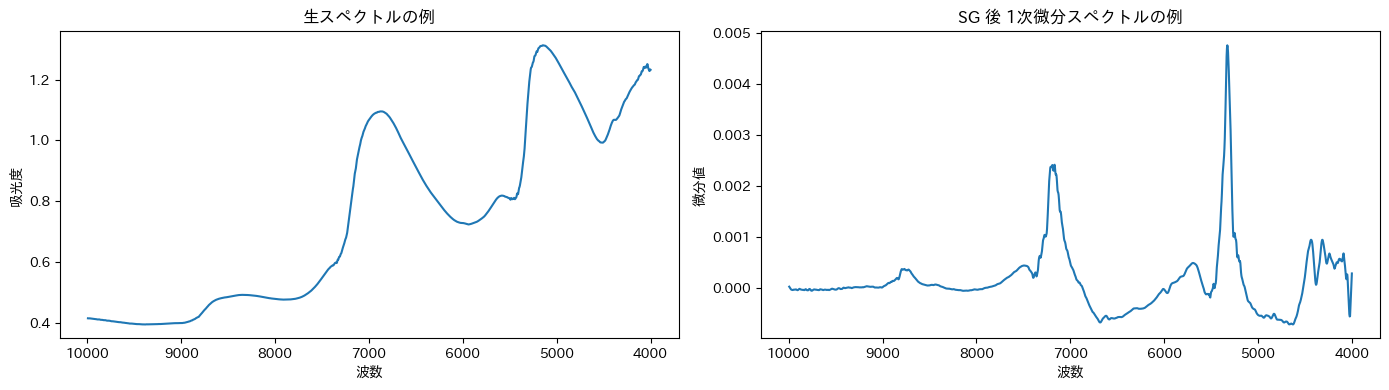

In [15]:
# ============================================================
# 生スペクトルと SG 後 1 次微分スペクトルの見た目確認
# ============================================================
example_idx = 0

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(wave_numbers, X_train_raw[example_idx, 0])
plt.gca().invert_xaxis()
plt.title('生スペクトルの例')
plt.xlabel('波数')
plt.ylabel('吸光度')

plt.subplot(1, 2, 2)
plt.plot(wave_numbers, X_train_raw[example_idx, 1])
plt.gca().invert_xaxis()
plt.title('SG 後 1次微分スペクトルの例')
plt.xlabel('波数')
plt.ylabel('微分値')

plt.tight_layout()
plt.show()


In [16]:
# ============================================================
# Dataset・Model・学習関数の定義
# ============================================================
def scale_multichannel_features(
    train_x: np.ndarray,
    valid_x: np.ndarray,
    test_x: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, list]:
    """チャネルごとに scaler を fit して標準化する関数。"""
    train_scaled = np.empty_like(train_x)
    valid_scaled = np.empty_like(valid_x)
    test_scaled = np.empty_like(test_x)
    scalers = []

    for channel_idx in range(train_x.shape[1]):
        scaler = StandardScaler()
        train_scaled[:, channel_idx, :] = scaler.fit_transform(train_x[:, channel_idx, :])
        valid_scaled[:, channel_idx, :] = scaler.transform(valid_x[:, channel_idx, :])
        test_scaled[:, channel_idx, :] = scaler.transform(test_x[:, channel_idx, :])
        scalers.append(scaler)

    return train_scaled, valid_scaled, test_scaled, scalers


class SpectralDataset(Dataset):
    """多チャネルスペクトル配列と目的変数を PyTorch 用に受け渡す Dataset。"""

    def __init__(self, x: np.ndarray, y: np.ndarray | None = None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y[:, None], dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx: int):
        if self.y is None:
            return self.x[idx]
        return self.x[idx], self.y[idx]


class ConvBlock(nn.Module):
    """畳み込み + BatchNorm + ReLU をまとめた再利用用ブロック。"""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 7):
        super().__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SpectralCNN(nn.Module):
    """生スペクトル + SG 後 1 次微分スペクトルの 2 チャネル入力を扱う 1 次元 CNN。"""

    def __init__(self, in_channels: int = 2, dropout: float = 0.2):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(in_channels, 32, kernel_size=9),
            ConvBlock(32, 64, kernel_size=7),
            ConvBlock(64, 128, kernel_size=5),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        x = self.regressor(x)
        return x


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
) -> float:
    """1 エポック分だけ学習し、平均損失を返す。"""
    model.train()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


def valid_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> Tuple[float, float, np.ndarray]:
    """検証データで損失と RMSE を計算し、予測値も返す。"""
    model.eval()
    total_loss = 0.0
    preds_list = []
    target_list = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item() * x_batch.size(0)

            preds_list.append(preds.detach().cpu().numpy().reshape(-1))
            target_list.append(y_batch.detach().cpu().numpy().reshape(-1))

    preds_np = np.concatenate(preds_list)
    targets_np = np.concatenate(target_list)
    avg_loss = total_loss / len(loader.dataset)
    rmse = rmse_score(targets_np, preds_np)
    return avg_loss, rmse, preds_np


def predict_with_model(model: nn.Module, loader: DataLoader) -> np.ndarray:
    """1 つの学習済みモデルで推論し、予測値を配列で返す。"""
    model.eval()
    preds_list = []

    with torch.no_grad():
        for x_batch in loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            preds_list.append(preds.detach().cpu().numpy().reshape(-1))

    return np.concatenate(preds_list)


In [17]:
# ============================================================
# GroupKFold による学習と OOF 予測
# ============================================================
def run_group_cv(
    x: np.ndarray,
    y: np.ndarray,
    groups: np.ndarray,
    x_test: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, list, list]:
    """
    sample number 単位で GroupKFold を行い、
    各 fold の最良モデル・OOF 予測・テスト予測平均を返す関数。
    """
    splitter = GroupKFold(n_splits=CFG.n_splits)

    oof_preds = np.zeros(len(x), dtype=np.float32)
    test_preds = np.zeros(len(x_test), dtype=np.float32)
    models = []
    history = []

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(x, y, groups), start=1):
        print('=' * 70)
        print(f'Fold {fold}/{CFG.n_splits}')

        x_train_fold, x_valid_fold, x_test_fold, _ = scale_multichannel_features(
            x[train_idx],
            x[valid_idx],
            x_test,
        )

        train_dataset = SpectralDataset(x_train_fold, y[train_idx])
        valid_dataset = SpectralDataset(x_valid_fold, y[valid_idx])
        test_dataset = SpectralDataset(x_test_fold)

        train_loader = DataLoader(
            train_dataset,
            batch_size=CFG.batch_size,
            shuffle=True,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
        )
        valid_loader = DataLoader(
            valid_dataset,
            batch_size=CFG.batch_size,
            shuffle=False,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=CFG.batch_size,
            shuffle=False,
            num_workers=CFG.num_workers,
            pin_memory=torch.cuda.is_available(),
        )

        model = SpectralCNN(in_channels=CFG.in_channels, dropout=CFG.dropout).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=CFG.learning_rate,
            weight_decay=CFG.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=3,
        )

        best_rmse = np.inf
        best_state = None
        patience_counter = 0
        fold_log = []

        for epoch in range(1, CFG.epochs + 1):
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
            valid_loss, valid_rmse, _ = valid_one_epoch(model, valid_loader, criterion)
            scheduler.step(valid_rmse)

            current_lr = optimizer.param_groups[0]['lr']
            fold_log.append(
                {
                    'fold': fold,
                    'epoch': epoch,
                    'train_loss': train_loss,
                    'valid_loss': valid_loss,
                    'valid_rmse': valid_rmse,
                    'lr': current_lr,
                }
            )

            print(
                f'Epoch {epoch:02d} | '
                f'train_loss={train_loss:.4f} | '
                f'valid_loss={valid_loss:.4f} | '
                f'valid_rmse={valid_rmse:.4f} | '
                f'lr={current_lr:.6f}'
            )

            if valid_rmse < best_rmse:
                best_rmse = valid_rmse
                best_state = deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= CFG.patience:
                print(f'早期終了: {CFG.patience} エポック改善しなかったため終了します。')
                break

        model.load_state_dict(best_state)
        _, best_valid_rmse, valid_preds = valid_one_epoch(model, valid_loader, criterion)
        oof_preds[valid_idx] = valid_preds
        fold_test_preds = predict_with_model(model, test_loader)
        test_preds += fold_test_preds / CFG.n_splits

        model_save_path = CFG.MODEL_PATH / f'model_ver05_fold{fold}.pth'
        torch.save(model.state_dict(), model_save_path)
        print(f'Fold {fold} best RMSE: {best_valid_rmse:.4f}')
        print(f'モデル保存先: {model_save_path}')

        models.append(model)
        history.extend(fold_log)

        del train_dataset, valid_dataset, test_dataset
        del train_loader, valid_loader, test_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return oof_preds, test_preds, models, history


In [18]:
# ============================================================
# 学習・OOF 評価・提出ファイル保存
# ============================================================
oof_preds, test_preds, models, history = run_group_cv(
    x=X_train_raw,
    y=y_train,
    groups=groups,
    x_test=X_test_raw,
)

cv_rmse = rmse_score(y_train, oof_preds)
print('=' * 70)
print(f'CV RMSE: {cv_rmse:.4f}')

oof_df = train_df[['sample number', 'species number', '樹種', '含水率']].copy()
oof_df['oof_pred'] = oof_preds
oof_df.to_csv(CFG.OUTPUT_PATH / 'model_ver05_oof.csv', index=False, encoding='utf-8-sig')

pred_df = test_df[['sample number', 'species number', '樹種']].copy()
pred_df['pred'] = test_preds
pred_df.to_csv(CFG.OUTPUT_PATH / 'model_ver05_test_pred.csv', index=False, encoding='utf-8-sig')


def save_submission(predictions: np.ndarray) -> Path:
    """サンプル提出ファイルの形式で予測値を書き出す関数。"""
    submit_df = sample_submit_df.copy()
    submit_df[1] = predictions
    save_path = CFG.OUTPUT_PATH / 'model_ver05_submission.csv'
    submit_df.to_csv(save_path, header=False, index=False)
    return save_path


submission_path = save_submission(test_preds)
print(f'提出ファイル保存先: {submission_path}')


Fold 1/5
Epoch 01 | train_loss=4790.1071 | valid_loss=4663.0481 | valid_rmse=68.2865 | lr=0.001000
Epoch 02 | train_loss=4110.1745 | valid_loss=3715.6617 | valid_rmse=60.9562 | lr=0.001000
Epoch 03 | train_loss=2929.4542 | valid_loss=2272.8311 | valid_rmse=47.6742 | lr=0.001000
Epoch 04 | train_loss=1701.3172 | valid_loss=1622.8386 | valid_rmse=40.2845 | lr=0.001000
Epoch 05 | train_loss=1117.0916 | valid_loss=1121.5928 | valid_rmse=33.4902 | lr=0.001000
Epoch 06 | train_loss=881.7213 | valid_loss=986.0147 | valid_rmse=31.4009 | lr=0.001000
Epoch 07 | train_loss=927.8422 | valid_loss=766.2107 | valid_rmse=27.6805 | lr=0.001000
Epoch 08 | train_loss=850.9852 | valid_loss=646.1987 | valid_rmse=25.4204 | lr=0.001000
Epoch 09 | train_loss=783.0740 | valid_loss=678.9548 | valid_rmse=26.0568 | lr=0.001000
Epoch 10 | train_loss=669.7656 | valid_loss=539.1916 | valid_rmse=23.2205 | lr=0.001000
Epoch 11 | train_loss=581.3872 | valid_loss=495.6867 | valid_rmse=22.2640 | lr=0.001000
Epoch 12 | tr

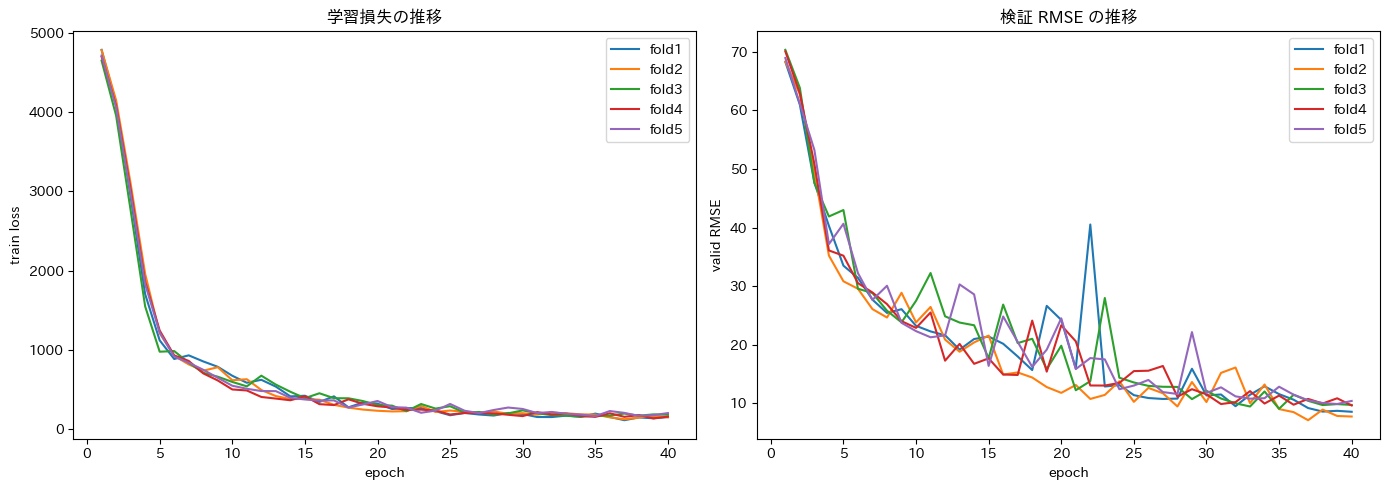

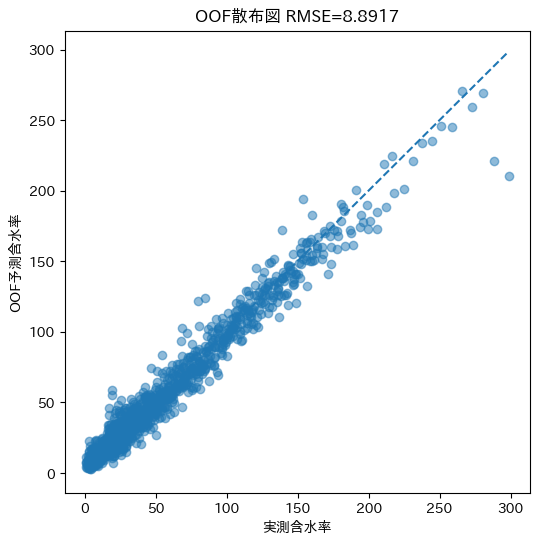

In [19]:
# ============================================================
# 学習結果の可視化
# ============================================================
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold, fold_df in history_df.groupby('fold'):
    axes[0].plot(fold_df['epoch'], fold_df['train_loss'], label=f'fold{fold}')
    axes[1].plot(fold_df['epoch'], fold_df['valid_rmse'], label=f'fold{fold}')

axes[0].set_title('学習損失の推移')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('train loss')
axes[0].legend()

axes[1].set_title('検証 RMSE の推移')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('valid RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_train, oof_preds, alpha=0.5)
line_min = min(y_train.min(), oof_preds.min())
line_max = max(y_train.max(), oof_preds.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.xlabel('実測含水率')
plt.ylabel('OOF予測含水率')
plt.title(f'OOF散布図 RMSE={cv_rmse:.4f}')
plt.show()


## 補足

- `model_ver05` のポイントは、**微分をそのまま取るのではなく、Savitzky-Golay フィルタで平滑化しながら 1 次微分を計算していること**です。
- 今回は比較のしやすさを優先し、入力は `生スペクトル + SG 後 1次微分スペクトル` の 2 チャネルにしています。
- ここからさらに発展させるなら、次の比較がしやすいです。
  - SG 後の平滑スペクトル自体もチャネルとして追加する
  - `raw + SG 1次微分 + SG 2次微分` の 3 チャネル化
  - `sg_window_length` と `sg_polyorder` のチューニング
